In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys


# sys.path.append("../src")

from src.feature_extraction import create_advanced_features

plt.style.use('seaborn-v0_8-darkgrid')

In [ ]:
# Load Processed Data
df = pd.read_csv("data/processed/cleaned_traffic.csv")

print("Dataset Loaded Successfully")
print("Shape:", df.shape)

df.head()

Dataset Loaded Successfully
Shape: (48120, 10)


,DateTime,Junction,Vehicles,Hour,Day,DayOfWeek,Month,Year,Is_Weekend,Is_Peak_Hour
0,2015-11-01 00:00:00,1,15,0,1,6,11,2015,1,0
1,2015-11-01 01:00:00,1,13,1,1,6,11,2015,1,0
2,2015-11-01 02:00:00,1,10,2,1,6,11,2015,1,0
3,2015-11-01 03:00:00,1,7,3,1,6,11,2015,1,0
4,2015-11-01 04:00:00,1,9,4,1,6,11,2015,1,0


In [8]:
# Check Columns
print("Columns in dataset:")
print(df.columns)

Columns in dataset:
Index(['DateTime', 'Junction', 'Vehicles', 'Hour', 'Day', 'DayOfWeek', 'Month',
       'Year', 'Is_Weekend', 'Is_Peak_Hour'],
      dtype='object')


In [9]:
# Create Advanced Features
df = create_advanced_features(df)

print("Advanced features created successfully!")
df.head()

Advanced features created successfully!


,DateTime,Junction,Vehicles,Hour,Day,DayOfWeek,Month,Year,Is_Weekend,Is_Peak_Hour,lag_1,rolling_mean_3
0,2015-11-01 00:00:00,1,15,0,1,6,11,2015,1,0,15.0,12.666667
1,2015-11-01 01:00:00,1,13,1,1,6,11,2015,1,0,15.0,12.666667
2,2015-11-01 02:00:00,1,10,2,1,6,11,2015,1,0,13.0,12.666667
3,2015-11-01 03:00:00,1,7,3,1,6,11,2015,1,0,10.0,10.000000
4,2015-11-01 04:00:00,1,9,4,1,6,11,2015,1,0,7.0,8.666667


In [10]:
# Handle Missing Values (Important after lag features)
df = df.dropna().reset_index(drop=True)

print("Data after handling lag missing values:")
print(df.shape)

Data after handling lag missing values:
(48120, 12)


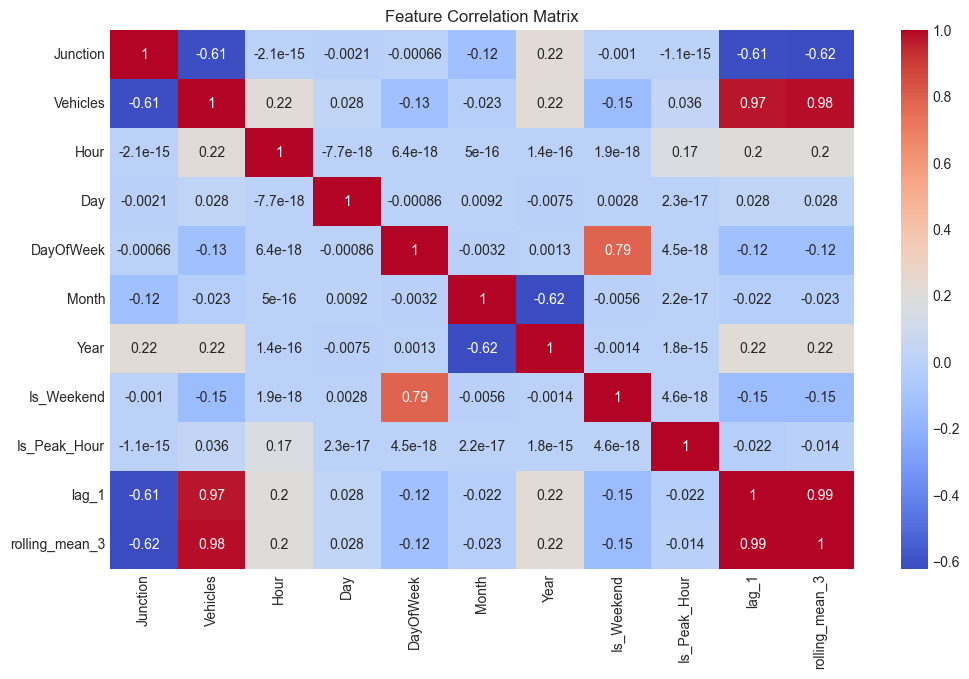

In [11]:
# Correlation Matrix
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(12,7))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

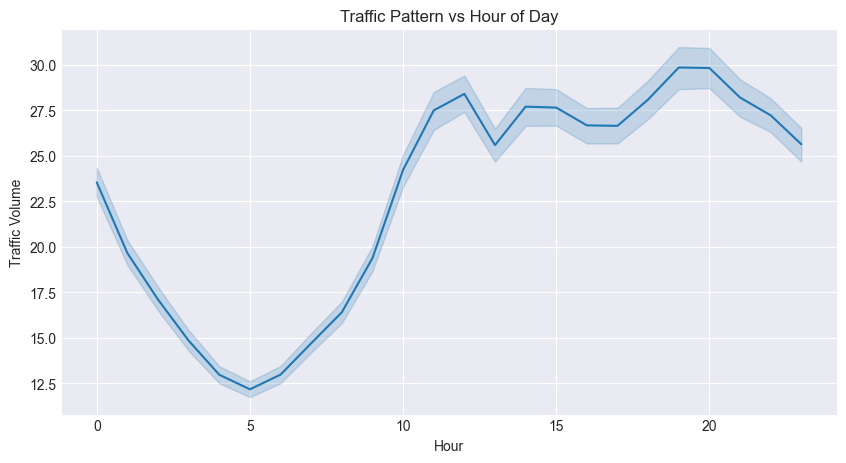

In [12]:
# Traffic vs Hour (Pattern Learning)
plt.figure(figsize=(10,5))
sns.lineplot(x=df['Hour'], y=df['Vehicles'])
plt.title("Traffic Pattern vs Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Traffic Volume")
plt.show()

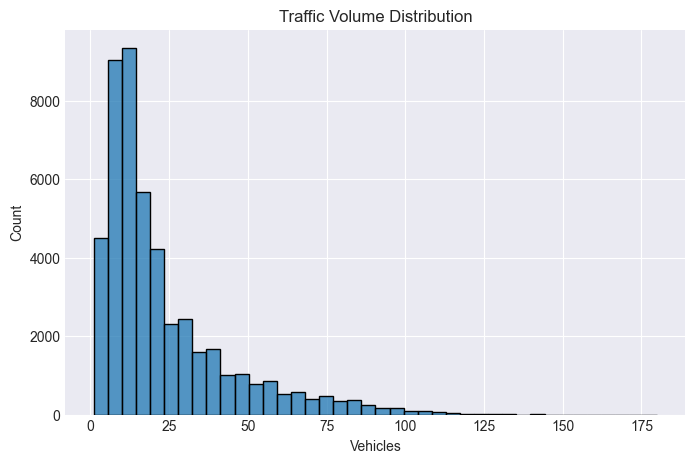

In [13]:
# Traffic Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Vehicles'], bins=40)
plt.title("Traffic Volume Distribution")
plt.show()

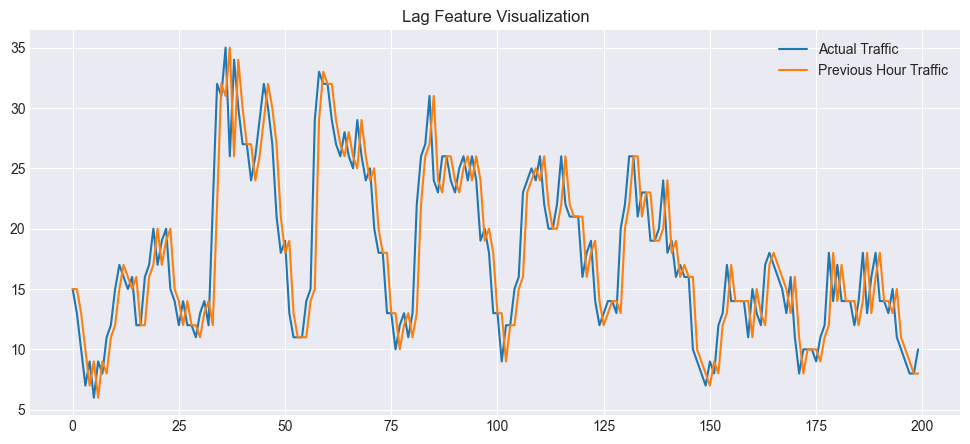

In [14]:
#Lag Feature Visualization
#This shows time-series behavior
plt.figure(figsize=(12,5))
plt.plot(df['Vehicles'][:200], label="Actual Traffic")
plt.plot(df['lag_1'][:200], label="Previous Hour Traffic")
plt.legend()
plt.title("Lag Feature Visualization")
plt.show()

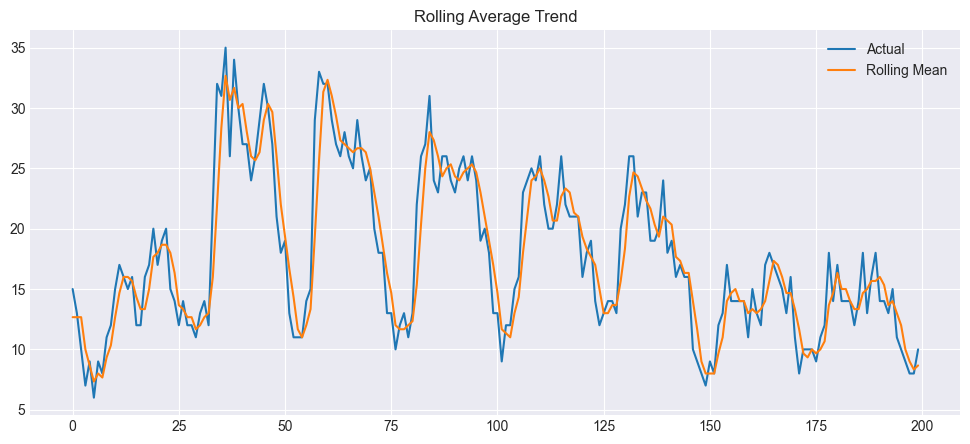

In [15]:
#Rolling Mean Trend
plt.figure(figsize=(12,5))
plt.plot(df['Vehicles'][:200], label="Actual")
plt.plot(df['rolling_mean_3'][:200], label="Rolling Mean")
plt.legend()
plt.title("Rolling Average Trend")
plt.show()

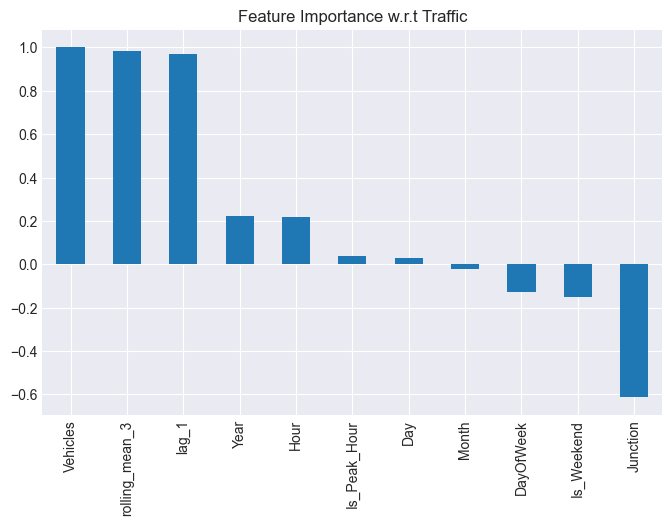

In [16]:
#Feature Importance Insight
corr_target = numeric_df.corr()['Vehicles'].sort_values(ascending=False)

plt.figure(figsize=(8,5))
corr_target.plot(kind='bar')
plt.title("Feature Importance w.r.t Traffic")
plt.show()

In [17]:
#Save Updated Dataset for Next Modules
df.to_csv("../data/processed/feature_engineered_traffic.csv", index=False)

print("Feature engineered dataset saved!")

Feature engineered dataset saved!
